# Analyse — prospects sécurité privée (NAF 80.10Z)

Données produites par `scripts/prospecting/fetch_securite_privee_sirene.py` (API [Recherche d'entreprises](https://api.gouv.fr/les-api/api-recherche-entreprises)).

**Prérequis** (dans l’environnement du notebook) :

```bash
pip install pandas matplotlib
```

Optionnel pour des graphiques plus soignés : `pip install seaborn`.

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Chemin relatif à la racine du dépôt Regultrack
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CSV_PATH = ROOT / "data" / "prospects_securite_8010z.csv"
assert CSV_PATH.is_file(), f"Fichier introuvable : {CSV_PATH} — lance le script d’export ou ajuste CSV_PATH."

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 60)

In [50]:
df = pd.read_csv(CSV_PATH, dtype={"siren": str, "siege_code_postal": str, "siege_departement": str})
df.head(10)

,siren,nom_complet,activite_principale,tranche_effectif_salarie,categorie_entreprise,nombre_etablissements_ouverts,siege_adresse,siege_code_postal,siege_commune,siege_departement,dirigeants
0,528697683,CAPITAL SECOURS (GROUPE CF MOYENS DE SECOURS),80.10Z,11,ETI,3,3 Rue Notre-Dame de Bon Secours 60200 Compiègne,60200,COMPIEGNE,60,DAVEY
1,814565461,AGENCE ROYALE SERVICES SECURITE PRIVEE (ARSSP),80.10Z,11,PME,3,16 Rue Sacrot 94160 Saint-Mandé,94160,SAINT-MANDE,94,ZAOUCH
2,538505520,FLASH ALARM (FLASH ALARME),80.10Z,11,PME,3,722 Avenue de Nice 06650 Le Rouret,06650,LE ROURET,06,GONZALES
3,491739454,SARL VIA SECURITE,80.10Z,11,PME,3,2 Place Alexandre Farnese 84000 Avignon,84000,AVIGNON,84,BEZOT (BARK)
4,381457472,TSIP,80.10Z,11,PME,2,73 ZA Domaine de Montvoisin 91400 Gometz-la-Ville,91400,GOMETZ-LA-VILLE,91,LE BIHAN | TIMAR-SCHUBERT | personne morale
5,491206397,SECURITY GUARDS ASSISTANCE,80.10Z,11,PME,2,264 Rue des Sables de Sary 45770 Saran,45770,SARAN,45,LAFITTE
6,451313761,JIDEM SECURITE (JIDEM SECURITE),80.10Z,11,PME,2,23 Place de la République 57310 Guénange,57310,GUENANGE,57,BOUBRIMA
7,440188548,BARKENE SERVICES (BARKENE SERVICES (EX LFT)),80.10Z,11,ETI,2,25 Rue du Closeau 77170 Brie-Comte-Robert,77170,BRIE-COMTE-ROBERT,77,personne morale
8,415259159,ALARM'VEILLE (ALARM'VEILLE),80.10Z,11,ETI,2,13 Rue Paul Sejourne 94000 Créteil,94000,CRETEIL,94,personne morale
9,810890574,PROTECTZONE,80.10Z,11,PME,2,28 Rue de l’Église 95170 Deuil-la-Barre,95170,DEUIL-LA-BARRE,95,SAOU


## 1. Vue d’ensemble

In [51]:
print(f"Lignes : {len(df):,}  |  Colonnes : {df.shape[1]}")
print(f"SIREN uniques : {df['siren'].nunique():,}")
dup = df['siren'].duplicated().sum()
print(f"Doublons SIREN : {dup}")
df.dtypes

Lignes : 1,691  |  Colonnes : 11
SIREN uniques : 1,691
Doublons SIREN : 0


siren                              str
nom_complet                        str
activite_principale                str
tranche_effectif_salarie         int64
categorie_entreprise               str
nombre_etablissements_ouverts    int64
siege_adresse                      str
siege_code_postal                  str
siege_commune                      str
siege_departement                  str
dirigeants                         str
dtype: object

In [52]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (100 * missing / len(df)).round(1)
pd.DataFrame({"manquants": missing, "%": missing_pct}).query("manquants > 0")

,manquants,%
dirigeants,10,0.6
siege_departement,1,0.1
siege_code_postal,1,0.1
siege_commune,1,0.1


## 2. Tranche d’effectif (INSEE)

Libellés indicatifs — nomenclature Sirene (niveau unité légale).

In [53]:
TRANCHE_LABELS = {
    "NN": "Non employeuse / non renseigné",
    "00": "0 salarié",
    "01": "1 ou 2",
    "02": "3 à 5",
    "03": "6 à 9",
    "11": "10 à 19",
    "12": "20 à 49",
    "22": "50 à 99",
    "31": "100 à 199",
    "32": "200 à 249",
    "41": "250 à 499",
    "42": "500 à 999",
    "51": "1 000 à 1 999",
    "52": "2 000 à 4 999",
    "53": "5 000 et plus",
}

df["tranche_libelle"] = df["tranche_effectif_salarie"].astype(str).map(TRANCHE_LABELS).fillna("(autre)")
vc_t = df["tranche_effectif_salarie"].value_counts().sort_index()
tbl = vc_t.rename("nombre").reset_index()
tbl.columns = ["tranche_code", "nombre"]
tbl["libelle"] = tbl["tranche_code"].astype(str).map(TRANCHE_LABELS).fillna("(autre)")
tbl

,tranche_code,nombre,libelle
0,11,690,10 à 19
1,12,726,20 à 49
2,22,147,50 à 99
3,31,35,100 à 199
4,32,44,200 à 249
5,41,24,250 à 499
6,42,10,500 à 999
7,51,12,1 000 à 1 999
8,52,2,2 000 à 4 999
9,53,1,5 000 et plus


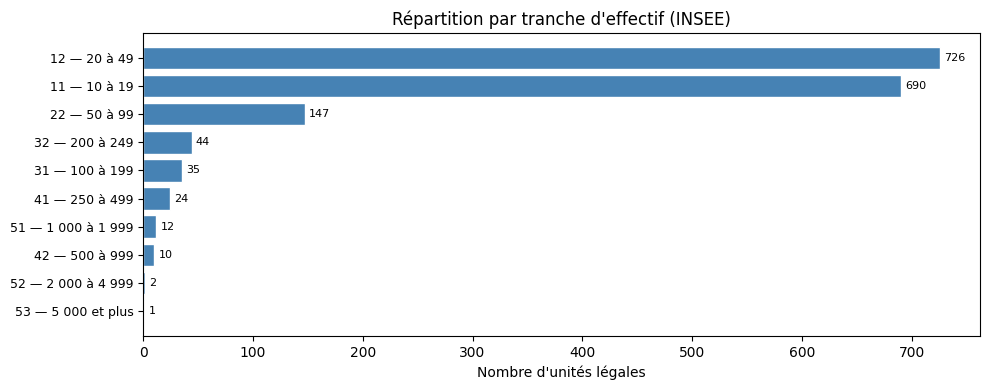

In [54]:
plot_tbl = tbl.sort_values("nombre", ascending=True)
codes = plot_tbl["tranche_code"].astype(str)
y_labels = [f"{c} — {TRANCHE_LABELS.get(c, c)}" for c in codes]
fig_h = max(4.0, 0.38 * len(plot_tbl))
fig, ax = plt.subplots(figsize=(10, fig_h))
bars = ax.barh(range(len(plot_tbl)), plot_tbl["nombre"].values, color="steelblue", edgecolor="white")
ax.set_yticks(range(len(plot_tbl)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel("Nombre d'unités légales")
ax.set_title("Répartition par tranche d'effectif (INSEE)")
ax.bar_label(bars, labels=[f"{int(v)}" for v in plot_tbl["nombre"].values], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 3. Catégorie d’entreprise (PME / ETI / GE)

,nombre
categorie_entreprise,
PME,1518
ETI,146
GE,27


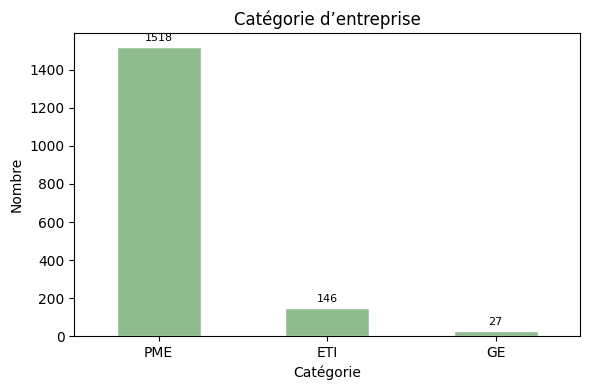

In [55]:
vc_cat = df["categorie_entreprise"].fillna("(non renseigné)").value_counts()
display(vc_cat.to_frame("nombre"))

fig, ax = plt.subplots(figsize=(6, 4))
vc_cat.plot(kind="bar", ax=ax, color="darkseagreen", edgecolor="white")
ax.set_ylabel("Nombre")
ax.set_xlabel("Catégorie")
ax.set_title("Catégorie d’entreprise")
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Département du siège (top 20)

,nombre
siege_departement,
93,166
75,159
13,92
94,76
95,74
92,74
69,52
31,51
06,50


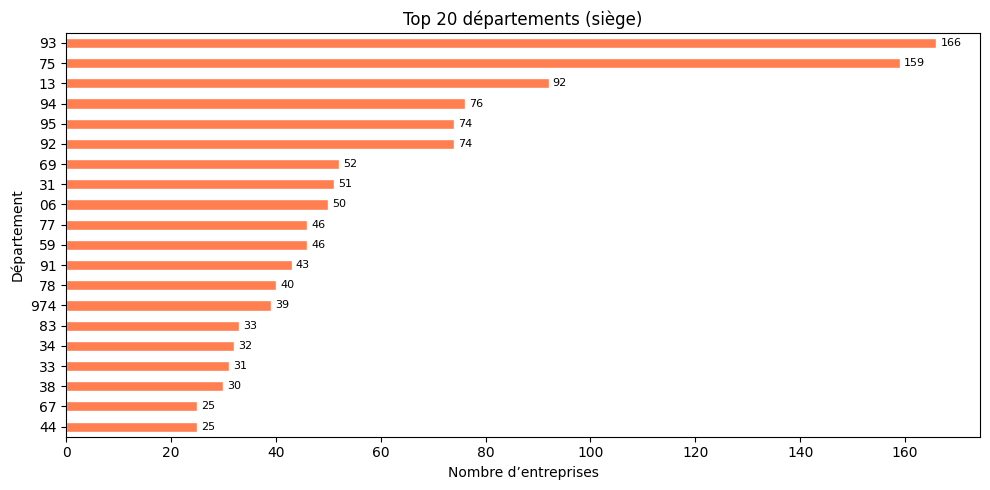

In [56]:
dept = df["siege_departement"].fillna("(manquant)").astype(str).str.zfill(2)
vc_dept = dept.value_counts().head(20)
display(vc_dept.to_frame("nombre"))

fig, ax = plt.subplots(figsize=(10, 5))
vc_dept.plot(kind="barh", ax=ax, color="coral", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Nombre d’entreprises")
ax.set_ylabel("Département")
ax.set_title("Top 20 départements (siège)")
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

## 5. Nombre d’établissements ouverts

count    1691.00
mean        1.49
std         3.34
min         0.00
25%         1.00
50%         1.00
75%         1.00
max        75.00


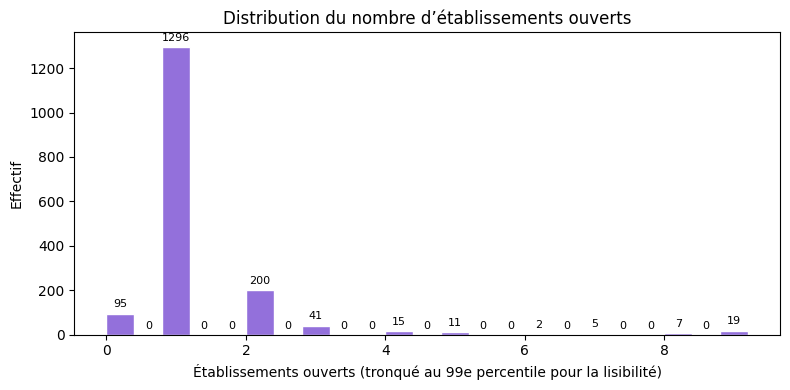

In [57]:
neo = pd.to_numeric(df["nombre_etablissements_ouverts"], errors="coerce")
print(neo.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bins = min(40, max(10, neo.dropna().nunique()))
counts, bin_edges, patches = ax.hist(neo.dropna().clip(upper=neo.quantile(0.99)), bins=bins, color="mediumpurple", edgecolor="white")
for count, patch in zip(counts, patches):
    ax.annotate(
        f"{int(count)}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xlabel("Établissements ouverts (tronqué au 99e percentile pour la lisibilité)")
ax.set_ylabel("Effectif")
ax.set_title("Distribution du nombre d’établissements ouverts")
plt.tight_layout()
plt.show()

## 6. Dirigeants renseignés dans l’API

In [58]:
dir_col = df["dirigeants"].fillna("").astype(str).str.strip()
has_dir = (dir_col != "") & (~dir_col.str.lower().isin(["nan", "none"]))
print(f"Lignes avec dirigeant(s) texte non vide : {has_dir.sum():,} ({100 * has_dir.mean():.1f} %)")

nb_parts = dir_col.str.count(r"\|") + 1
nb_parts = nb_parts.where(has_dir, 0)
print("Nombre de blocs séparés par « | » (plusieurs entrées possibles) :")
display(nb_parts.value_counts().sort_index().head(15).to_frame("lignes"))

Lignes avec dirigeant(s) texte non vide : 1,681 (99.4 %)
Nombre de blocs séparés par « | » (plusieurs entrées possibles) :


,lignes
dirigeants,
0,10
1,1351
2,179
3,108
4,27
5,9
6,1
7,2
8,2


## 7. Échantillon pour prospection (ex. PME, 10–49 salariés, 2+ sites)

À adapter selon ton ICP ; filtre d’exemple ci-dessous.

In [59]:
mask_icp = (
    df["categorie_entreprise"].eq("PME")
    & df["tranche_effectif_salarie"].astype(str).isin(["11", "12"])
    & (pd.to_numeric(df["nombre_etablissements_ouverts"], errors="coerce") >= 2)
)
shortlist = df.loc[mask_icp, ["siren", "nom_complet", "tranche_libelle", "nombre_etablissements_ouverts", "siege_commune", "siege_departement", "dirigeants"]].copy()
print(f"Shortlist (exemple ICP) : {len(shortlist):,} lignes")
shortlist.head(15)

Shortlist (exemple ICP) : 150 lignes


,siren,nom_complet,tranche_libelle,nombre_etablissements_ouverts,siege_commune,siege_departement,dirigeants
1,814565461,AGENCE ROYALE SERVICES SECURITE PRIVEE (ARSSP),10 à 19,3,SAINT-MANDE,94,ZAOUCH
2,538505520,FLASH ALARM (FLASH ALARME),10 à 19,3,LE ROURET,06,GONZALES
3,491739454,SARL VIA SECURITE,10 à 19,3,AVIGNON,84,BEZOT (BARK)
4,381457472,TSIP,10 à 19,2,GOMETZ-LA-VILLE,91,LE BIHAN | TIMAR-SCHUBERT | personne morale
5,491206397,SECURITY GUARDS ASSISTANCE,10 à 19,2,SARAN,45,LAFITTE
6,451313761,JIDEM SECURITE (JIDEM SECURITE),10 à 19,2,GUENANGE,57,BOUBRIMA
9,810890574,PROTECTZONE,10 à 19,2,DEUIL-LA-BARRE,95,SAOU
10,811845106,NC SECURITE PRIVEE,10 à 19,2,FREJUS,83,FEZAI
11,438072878,CHR SECURITE,10 à 19,2,MARSEILLE,13,RIPORTELLA
12,879566230,PROTECT EVENEMENT SERVICE (VGP SECURITE) (P.E.S.),10 à 19,2,AIX-EN-PROVENCE,13,KOESE


In [ ]:
# Export optionnel pour travail dans un tableur
OUT = ROOT / "data" / "prospects_shortlist_icp_exemple.csv"
# shortlist.to_csv(OUT, index=False)
# print("Écrit :", OUT)

: 